#Problem Statement: How the AI Revolution is Reshaping Data Science Careers?

#Datasets used:
##Dataset 1 - Primary Dataset that shows the real Data Science job market in AI era
"AI-Powered Job Market Insights"
https://www.kaggle.com/datasets/uom190346a/ai-powered-job-market-insights

##Dataset 2 - Evidence Dataset that gives the real data about layoffs
"Tech Layoffs 2020–2025"
https://www.kaggle.com/datasets/ulrikeherold/tech-layoffs-2020-2024

##Combined Dataset - On which the whole project is made
"AI Revolution & Data Science Job Market"
https://www.kaggle.com/datasets/shakshiiiiiiiiiii/ai-revolution-and-data-science-job-market

Combination Process:

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving ai_job_market_insights.csv to ai_job_market_insights.csv
Saving cleaned_ai_disruption_index.csv to cleaned_ai_disruption_index.csv
Saving tech_layoffs_til_2025.csv to tech_layoffs_til_2025.csv


In [ ]:
import pandas as pd
import numpy as np

df1 = pd.read_csv('ai_job_market_insights.csv')
df2 = pd.read_csv('tech_layoffs_til_2025.csv')

print("Dataset 1 shape:", df1.shape)
print("Dataset 2 shape:", df2.shape)

print("\nDataset 1 sample:")
print(df1.head(3))

print("\nDataset 2 sample:")
print(df2.head(3))

print("\nDataset 1 columns:", df1.columns.tolist())
print("Dataset 2 columns:", df2.columns.tolist())

Dataset 1 shape: (500, 10)
Dataset 2 shape: (2412, 18)

Dataset 1 sample:
               Job_Title       Industry Company_Size   Location  \
0  Cybersecurity Analyst  Entertainment        Small      Dubai   
1   Marketing Specialist     Technology        Large  Singapore   
2          AI Researcher     Technology        Large  Singapore   

  AI_Adoption_Level Automation_Risk Required_Skills     Salary_USD  \
0            Medium            High    UX/UI Design  111392.165243   
1            Medium            High       Marketing   93792.562466   
2            Medium            High    UX/UI Design  107170.263069   

  Remote_Friendly Job_Growth_Projection  
0             Yes                Growth  
1              No               Decline  
2             Yes                Growth  

Dataset 2 sample:
   Nr        Company    Location_HQ                  Region     USState  \
0   1  Tamara Mellon    Los Angeles                   other  California   
1   2   HopSkipDrive    Los Angeles    

In [ ]:
df2['Laid_Off'].fillna(df2['Laid_Off'].median(), inplace=True)
df2['Percentage'].fillna(df2['Percentage'].median(), inplace=True)
df2['Money_Raised_in__mil'].fillna(0, inplace=True)

df1['Industry'] = df1['Industry'].str.strip().str.lower()
df2['Industry'] = df2['Industry'].str.strip().str.lower()

mapping = {
    'ai': 'technology', 'ai startup': 'technology',
    'ai chip startup': 'technology', 'cloud': 'technology',
    'cloud technology': 'technology', 'cloud technology company': 'technology',
    'computer and network security': 'technology', 'cybersecurity': 'technology',
    'data': 'technology', 'hardware': 'technology',
    'it services': 'technology', 'it services and it consulting': 'technology',
    'networking and security': 'technology', 'saas': 'technology',
    'software development': 'technology', 'semiconductors': 'technology',
    'semiconductor manufacturing': 'technology',
    'technology. information and internet': 'technology',
    'finance': 'financial services', 'fintech': 'financial services',
    'financial services': 'financial services', 'insurance': 'financial services',
    'crypto': 'financial services', 'venture capital fund': 'financial services',
    'venture capital and private equity principals': 'financial services',
    'biotechnology research': 'healthcare', 'fitness': 'healthcare',
    'wellness and fitness services': 'healthcare',
    'e-commerce': 'retail', 'consumer': 'retail', 'consumer services': 'retail',
    'e-learning': 'education', 'higher education': 'education',
    'higher education industry': 'education',
    'gaming': 'entertainment', 'computer games': 'entertainment',
    'game studio': 'entertainment', 'media': 'entertainment',
    'entertainment providers': 'entertainment', 'online gaming': 'entertainment',
    'automotive': 'transportation', 'automotive technology': 'transportation',
    'logistics': 'transportation', 'logistic': 'transportation',
    'transportion': 'transportation', 'travel': 'transportation',
    'construction': 'energy',
    'computers and electronics manufacturing': 'manufacturing',
    'motor vehicle manufacturing': 'manufacturing', 'electronics': 'manufacturing',
    'telecommunication': 'telecommunications',
}

df1['Industry'] = df1['Industry'].replace(mapping)
df2['Industry'] = df2['Industry'].replace(mapping)
df1['Industry'] = df1['Industry'].replace({'finance': 'financial services'})

valid = df1['Industry'].unique()
df2 = df2[df2['Industry'].isin(valid)]

layoff_by_industry = df2.groupby('Industry').agg(
    Total_Layoffs    = ('Laid_Off',             'sum'),
    Avg_Layoff_Pct   = ('Percentage',           'mean'),
    Layoff_Events    = ('Company',              'count'),
    Avg_Funds_Raised = ('Money_Raised_in__mil', 'mean')
).reset_index()

merged = pd.merge(df1, layoff_by_industry, on='Industry', how='left')

merged[['Total_Layoffs', 'Avg_Layoff_Pct',
        'Layoff_Events', 'Avg_Funds_Raised']] = \
merged[['Total_Layoffs', 'Avg_Layoff_Pct',
        'Layoff_Events', 'Avg_Funds_Raised']].fillna(0)

risk_levels = {'Low': 1, 'Moderate': 2, 'High': 3}
merged['Risk_Score'] = merged['Automation_Risk'].map(risk_levels)

merged['AI_Disruption_Score'] = (
    merged['Risk_Score'].rank(pct=True)     * 0.5 +
    merged['Total_Layoffs'].rank(pct=True)  * 0.3 +
    merged['Avg_Layoff_Pct'].rank(pct=True) * 0.2
)

merged['Salary_Per_Risk'] = merged['Salary_USD'] / merged['Risk_Score']

def get_career_safety(row):
    if row['AI_Disruption_Score'] > 0.66:
        return 'High Risk'
    elif row['AI_Disruption_Score'] > 0.33:
        return 'Medium Risk'
    else:
        return 'Low Risk'

merged['Career_Safety'] = merged.apply(get_career_safety, axis=1)

cols = [
    'Job_Title', 'Industry', 'Company_Size', 'Location',
    'AI_Adoption_Level', 'Automation_Risk', 'Required_Skills',
    'Salary_USD', 'Remote_Friendly', 'Job_Growth_Projection',
    'Total_Layoffs', 'Avg_Layoff_Pct', 'Layoff_Events', 'Avg_Funds_Raised',
    'Risk_Score', 'AI_Disruption_Score', 'Career_Safety', 'Salary_Per_Risk'
]
merged = merged[cols]

merged.to_csv('ai_disruption_index_final.csv', index=False)

print("Combined dataset shape:", merged.shape)
print("\nColumns:", merged.columns.tolist())
print("\nCareer Safety distribution:\n", merged['Career_Safety'].value_counts())
print("\nCombined dataset:")
print(merged.head(10))

/tmp/ipykernel_3843/1521082470.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df2['Laid_Off'].fillna(df2['Laid_Off'].median(), inplace=True)
/tmp/ipykernel_3843/1521082470.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

Combined dataset shape: (500, 18)

Columns: ['Job_Title', 'Industry', 'Company_Size', 'Location', 'AI_Adoption_Level', 'Automation_Risk', 'Required_Skills', 'Salary_USD', 'Remote_Friendly', 'Job_Growth_Projection', 'Total_Layoffs', 'Avg_Layoff_Pct', 'Layoff_Events', 'Avg_Funds_Raised', 'Risk_Score', 'AI_Disruption_Score', 'Career_Safety', 'Salary_Per_Risk']

Career Safety distribution:
 Career_Safety
Low Risk       241
Medium Risk    184
High Risk       75
Name: count, dtype: int64

Combined dataset:
               Job_Title            Industry Company_Size       Location  \
0  Cybersecurity Analyst       entertainment        Small          Dubai   
1   Marketing Specialist          technology        Large      Singapore   
2          AI Researcher          technology        Large      Singapore   
3          Sales Manager              retail        Small         Berlin   
4  Cybersecurity Analyst       entertainment        Small          Tokyo   
5            UX Designer           edu

In [ ]:
df3 = pd.read_csv('ai_disruption_index_final.csv')

print("Before reduction:", df3.shape)
print("\nCareer Safety before reduction:\n", df3['Career_Safety'].value_counts())

high_risk = df3[df3['Career_Safety'] == 'High Risk'].sample(n=34, random_state=42)
mid_risk  = df3[df3['Career_Safety'] == 'Medium Risk'].sample(n=33, random_state=42)
low_risk  = df3[df3['Career_Safety'] == 'Low Risk'].sample(n=33, random_state=42)

final = pd.concat([high_risk, mid_risk, low_risk]).reset_index(drop=True)

final.to_csv('ai_disruption_index_100.csv', index=False)

print("\nAfter reduction:", final.shape)
print("\nCareer Safety after reduction:\n", final['Career_Safety'].value_counts())
print("\nFinal 100 row dataset:")
print(final.head(10))

Before reduction: (500, 18)

Career Safety before reduction:
 Career_Safety
Low Risk       241
Medium Risk    184
High Risk       75
Name: count, dtype: int64

After reduction: (100, 18)

Career Safety after reduction:
 Career_Safety
High Risk      34
Medium Risk    33
Low Risk       33
Name: count, dtype: int64

Final 100 row dataset:
               Job_Title            Industry Company_Size       Location  \
0   Marketing Specialist  financial services        Small         London   
1          AI Researcher      transportation       Medium      Singapore   
2      Software Engineer          technology        Small          Paris   
3   Marketing Specialist          technology        Large      Singapore   
4         Data Scientist          healthcare       Medium         London   
5            UX Designer      transportation       Medium         Sydney   
6         Data Scientist  financial services       Medium         Sydney   
7   Marketing Specialist              retail        La

In [ ]:
df3.head(10)

,Job_Title,Industry,Company_Size,Location,AI_Adoption_Level,Automation_Risk,Required_Skills,Salary_USD,Remote_Friendly,Job_Growth_Projection,Total_Layoffs,Avg_Layoff_Pct,Layoff_Events,Avg_Funds_Raised,Risk_Score,AI_Disruption_Score,Career_Safety,Salary_Per_Risk
0,Cybersecurity Analyst,entertainment,Small,Dubai,Medium,High,UX/UI Design,111392.165243,Yes,Growth,15989.0,21.377193,114,2348.868421,3.0,0.55776,Medium Risk,37130.721748
1,Marketing Specialist,technology,Large,Singapore,Medium,High,Marketing,93792.562466,No,Decline,154263.0,20.916000,200,190.845000,3.0,0.68326,High Risk,31264.187489
2,AI Researcher,technology,Large,Singapore,Medium,High,UX/UI Design,107170.263069,Yes,Growth,154263.0,20.916000,200,190.845000,3.0,0.68326,High Risk,35723.421023
3,Sales Manager,retail,Small,Berlin,Low,High,Project Management,93027.953758,No,Growth,165096.0,24.354829,321,721.732087,3.0,0.77426,High Risk,31009.317919
4,Cybersecurity Analyst,entertainment,Small,Tokyo,Low,Low,JavaScript,87752.922171,Yes,Decline,15989.0,21.377193,114,2348.868421,1.0,0.30776,Low Risk,87752.922171
5,UX Designer,education,Large,San Francisco,Medium,Medium,Cybersecurity,102825.007867,No,Growth,13373.0,29.375000,80,197.300000,NaN,NaN,Low Risk,NaN
6,HR Manager,financial services,Medium,Singapore,Low,High,Sales,102065.720673,Yes,Growth,59169.0,24.013550,369,371.869919,3.0,0.66776,High Risk,34021.906891
7,Cybersecurity Analyst,technology,Small,Dubai,Medium,Low,Machine Learning,86607.317618,Yes,Decline,154263.0,20.916000,200,190.845000,1.0,0.43326,Medium Risk,86607.317618
8,AI Researcher,retail,Large,London,High,Low,JavaScript,75015.860846,No,Stable,165096.0,24.354829,321,721.732087,1.0,0.52426,Medium Risk,75015.860846
9,Sales Manager,entertainment,Medium,Singapore,High,Low,Cybersecurity,96834.578295,Yes,Decline,15989.0,21.377193,114,2348.868421,1.0,0.30776,Low Risk,96834.578295


Data Cleaning:

In [ ]:
df4 = pd.read_csv('ai_disruption_index_100.csv')
df4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Job_Title              100 non-null    object 
 1   Industry               100 non-null    object 
 2   Company_Size           100 non-null    object 
 3   Location               100 non-null    object 
 4   AI_Adoption_Level      100 non-null    object 
 5   Automation_Risk        100 non-null    object 
 6   Required_Skills        100 non-null    object 
 7   Salary_USD             100 non-null    float64
 8   Remote_Friendly        100 non-null    object 
 9   Job_Growth_Projection  100 non-null    object 
 10  Total_Layoffs          100 non-null    float64
 11  Avg_Layoff_Pct         100 non-null    float64
 12  Layoff_Events          100 non-null    int64  
 13  Avg_Funds_Raised       100 non-null    float64
 14  Risk_Score             78 non-null     float64
 15  AI_Disr

In [ ]:
df4.describe()

,Salary_USD,Total_Layoffs,Avg_Layoff_Pct,Layoff_Events,Avg_Funds_Raised,Risk_Score,AI_Disruption_Score,Salary_Per_Risk
count,100.000000,100.0000,100.000000,100.000000,100.000000,78.000000,78.000000,78.000000
mean,91134.547386,59148.8000,23.212879,172.540000,568.685682,2.333333,0.554096,50725.045542
std,20184.440159,55374.0308,4.284586,130.863212,668.242686,0.948911,0.164492,32530.729840
min,41298.726205,13323.0000,16.000000,2.000000,0.000000,1.000000,0.212160,13766.242068
25%,76621.073461,15400.0000,20.916000,43.000000,190.845000,1.000000,0.433260,29724.191260
50%,91836.865983,28827.0000,24.013550,182.000000,327.423077,3.000000,0.557760,33692.886047
75%,102633.395737,64890.0000,25.416400,321.000000,721.732087,3.000000,0.690010,74555.426040
max,155209.821614,165096.0000,29.375000,369.000000,2348.868421,3.000000,0.774260,148467.112346


In [ ]:
df4.isnull().sum()

,0
Job_Title,0
Industry,0
Company_Size,0
Location,0
AI_Adoption_Level,0
Automation_Risk,0
Required_Skills,0
Salary_USD,0
Remote_Friendly,0
Job_Growth_Projection,0


In [ ]:
df4.dropna(inplace=True)
df4.isnull().sum()

,0
Job_Title,0
Industry,0
Company_Size,0
Location,0
AI_Adoption_Level,0
Automation_Risk,0
Required_Skills,0
Salary_USD,0
Remote_Friendly,0
Job_Growth_Projection,0


In [ ]:
df4.duplicated().sum()

np.int64(0)

In [ ]:
#standardization
df4['Industry'] = df4['Industry'].str.lower()
df4['Location'] = df4['Location'].str.title()
df4['Job_Title'] = df4['Job_Title'].str.title()
df4.columns = df4.columns.str.lower().str.replace(" ", "_")

In [ ]:
num_cols = df4.select_dtypes(include=np.number).columns
outlier_summary = {}

for col in num_cols:
    Q1 = df4[col].quantile(0.25)
    Q3 = df4[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df4[(df4[col] < lower_bound) | (df4[col] > upper_bound)]
    outlier_summary[col] = len(outliers)
    print(f"{col}: {len(outliers)} outliers")

salary_usd: 2 outliers
total_layoffs: 14 outliers
avg_layoff_pct: 0 outliers
layoff_events: 0 outliers
avg_funds_raised: 6 outliers
risk_score: 0 outliers
ai_disruption_score: 0 outliers
salary_per_risk: 1 outliers


In [ ]:
for col in df4.select_dtypes(include=np.number).columns:
    Q1 = df4[col].quantile(0.25)
    Q3 = df4[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df4[col] = np.clip(df4[col], lower, upper)
print("Outliers capped successfully")

Outliers capped successfully


In [ ]:
df4.replace(["NA", "N/A", "null", ""], np.nan, inplace=True)

In [ ]:
for col in df4.select_dtypes(include='object').columns:
    df4[col].fillna(df4[col].mode()[0], inplace=True)

/tmp/ipykernel_3843/2660705504.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df4[col].fillna(df4[col].mode()[0], inplace=True)


In [ ]:
df4 = df4.apply(pd.to_numeric, errors='ignore')

/tmp/ipykernel_3843/1608245633.py:1: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df4 = df4.apply(pd.to_numeric, errors='ignore')


In [ ]:
df4.to_csv('cleaned_ai_disruption_index.csv', index=False)
from google.colab import files
files.download('cleaned_ai_disruption_index.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

EDA:
*   Analysis
*   Visualization
*   Skewness & Kurtosis
*   Symmetry check & conversion
* Descriptive statistics





In [ ]:
#Analysis on Data Sciene Field
ds_df = df4[df4['job_title'].str.contains('data', case=False, na=False)].copy()
ds_df

,job_title,industry,company_size,location,ai_adoption_level,automation_risk,required_skills,salary_usd,remote_friendly,job_growth_projection,total_layoffs,avg_layoff_pct,layoff_events,avg_funds_raised,risk_score,ai_disruption_score,career_safety,salary_per_risk
4,Data Scientist,healthcare,Medium,London,Medium,High,Data Analysis,45848.725494,Yes,Growth,28827.0,29.071429,182,327.423077,3.0,0.69226,High Risk,15282.908498
6,Data Scientist,financial services,Medium,Sydney,Medium,High,Sales,91321.911193,Yes,Decline,59169.0,24.013550,369,371.869919,3.0,0.66776,High Risk,30440.637064
33,Data Scientist,technology,Small,London,Medium,High,Cybersecurity,86925.248553,No,Decline,138241.5,20.916000,200,190.845000,3.0,0.68326,High Risk,28975.082851
44,Data Scientist,healthcare,Medium,Paris,High,Low,Python,137942.717355,Yes,Stable,28827.0,29.071429,182,327.423077,1.0,0.44226,Medium Risk,141802.278209
46,Data Scientist,education,Medium,San Francisco,Low,Low,Marketing,74767.081877,Yes,Stable,13373.0,29.375000,80,197.300000,1.0,0.35716,Medium Risk,74767.081877
49,Data Scientist,financial services,Large,Tokyo,Medium,Low,Sales,92027.134231,No,Growth,59169.0,24.013550,369,371.869919,1.0,0.41776,Medium Risk,92027.134231
53,Data Scientist,transportation,Small,San Francisco,Medium,Low,Data Analysis,119717.365510,Yes,Growth,64890.0,25.416400,250,1453.848000,1.0,0.48216,Medium Risk,119717.365510
54,Data Scientist,education,Small,New York,Medium,High,Project Management,101228.040997,Yes,Decline,13373.0,29.375000,80,197.300000,3.0,0.60716,Medium Risk,33742.680332
64,Data Scientist,telecommunications,Small,Sydney,Low,High,JavaScript,57499.280615,Yes,Decline,15400.0,16.000000,2,0.000000,3.0,0.46216,Medium Risk,19166.426872
75,Data Scientist,entertainment,Medium,Sydney,Low,Low,Sales,112234.371350,Yes,Stable,15989.0,21.377193,114,1518.062718,1.0,0.30776,Low Risk,112234.371350


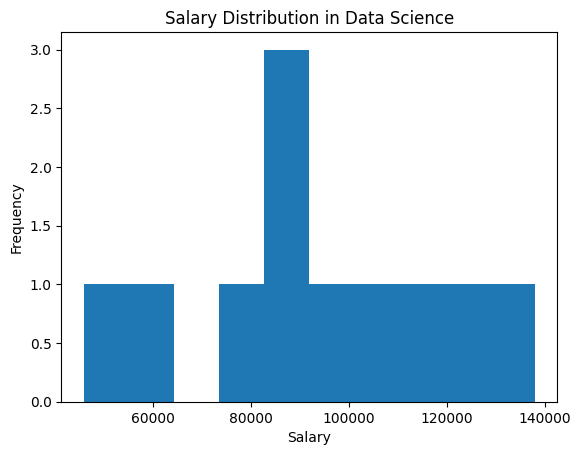

In [ ]:
import matplotlib.pyplot as plt

plt.hist(ds_df['salary_usd'])
plt.title("Salary Distribution in Data Science")
plt.xlabel("Salary")
plt.ylabel("Frequency")
plt.show()

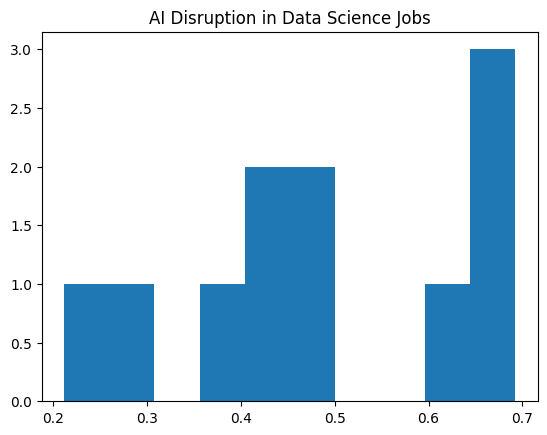

In [ ]:
plt.hist(ds_df['ai_disruption_score'])
plt.title("AI Disruption in Data Science Jobs")
plt.show()

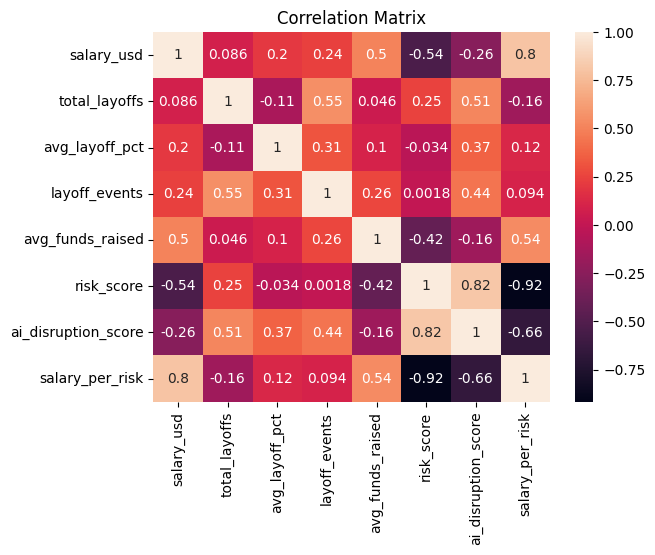

In [ ]:
import seaborn as sns
sns.heatmap(ds_df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.show()

The correlation matrix reveals that AI disruption is strongly positively correlated with job risk, indicating that increased AI adoption leads to higher job uncertainty. Additionally, risk score has a strong negative correlation with salary per risk, showing that high-risk roles provide lower value relative to compensation. Moderate correlation between layoffs and AI disruption suggests that automation contributes to workforce reductions.

In [ ]:
#Descriptive Analysis
ds_df.describe()

,salary_usd,total_layoffs,avg_layoff_pct,layoff_events,avg_funds_raised,risk_score,ai_disruption_score,salary_per_risk
count,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000
mean,91575.668666,41150.772727,24.057232,166.363636,450.540155,1.909091,0.484714,68725.131359
std,26518.836352,38007.568621,5.055499,127.447458,528.261326,1.044466,0.161141,45121.313354
min,45848.725494,13373.000000,16.000000,2.000000,0.000000,1.000000,0.212160,15282.908498
25%,80846.165215,15400.000000,21.146596,80.000000,194.072500,1.000000,0.387460,29707.859958
50%,91321.911193,28827.000000,24.013550,182.000000,327.423077,1.000000,0.462160,74767.081877
75%,106731.206174,59169.000000,29.071429,225.000000,371.869919,3.000000,0.637460,102130.752791
max,137942.717355,138241.500000,29.375000,369.000000,1518.062718,3.000000,0.692260,141802.278209



Skewness & Kurtosis Summary:



,Skewness,Kurtosis,Skew_Type,Kurt_Type
salary_usd,-0.055032,0.000404,Symmetric,Leptokurtic (Heavy Tails)
total_layoffs,1.877968,3.907677,Right Skewed,Leptokurtic (Heavy Tails)
avg_layoff_pct,-0.511723,-0.954495,Left Skewed,Platykurtic (Light Tails)
layoff_events,0.410884,-0.691607,Symmetric,Platykurtic (Light Tails)
avg_funds_raised,1.648986,1.501606,Right Skewed,Leptokurtic (Heavy Tails)
risk_score,0.212762,-2.444444,Symmetric,Platykurtic (Light Tails)
ai_disruption_score,-0.102697,-1.027760,Symmetric,Platykurtic (Light Tails)
salary_per_risk,0.251402,-1.529501,Symmetric,Platykurtic (Light Tails)
total_layoffs_log,0.650981,-0.798503,Right Skewed,Platykurtic (Light Tails)
avg_funds_raised_log,-1.545991,1.352799,Left Skewed,Leptokurtic (Heavy Tails)


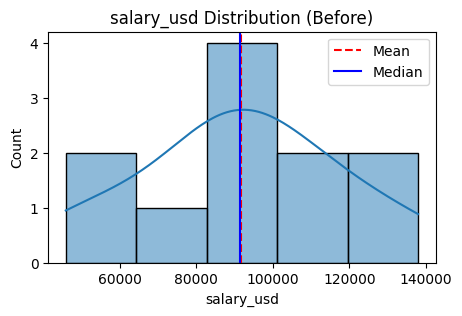

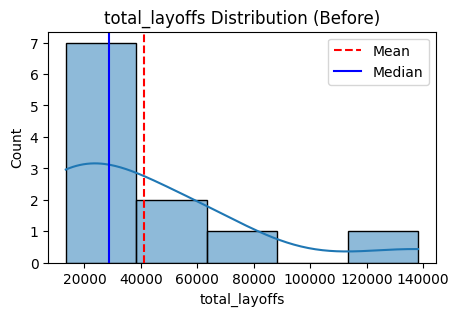

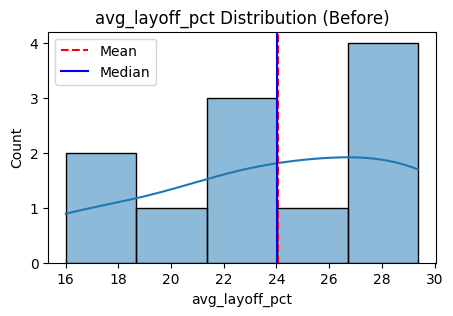

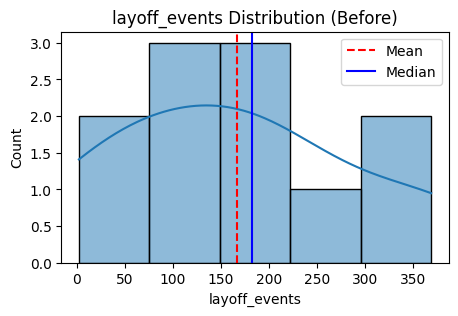

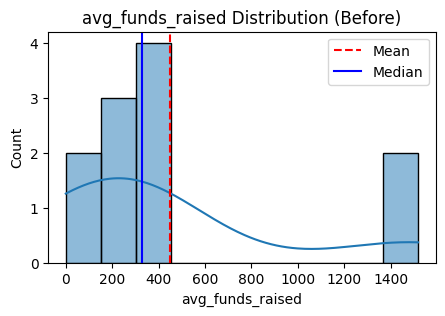

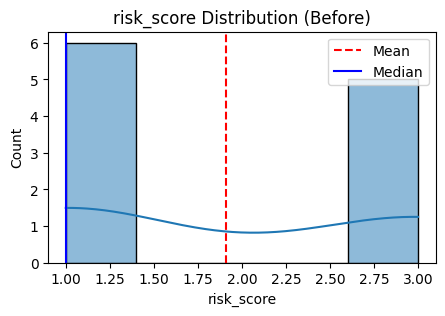

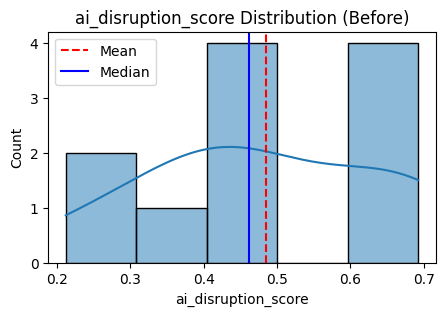

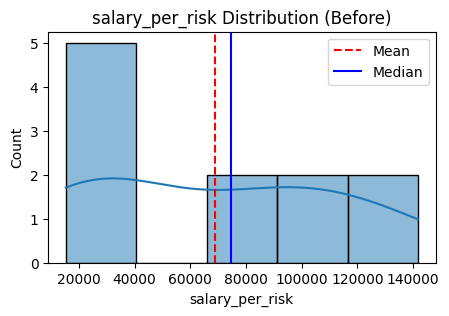

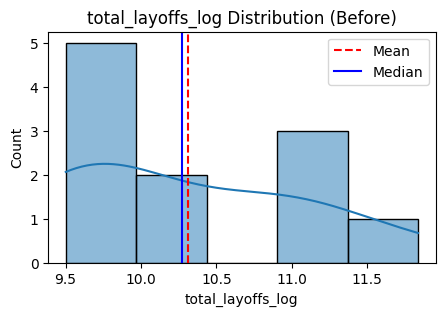

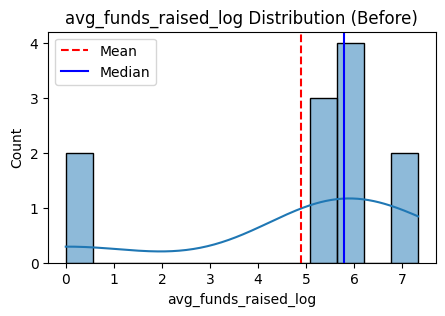

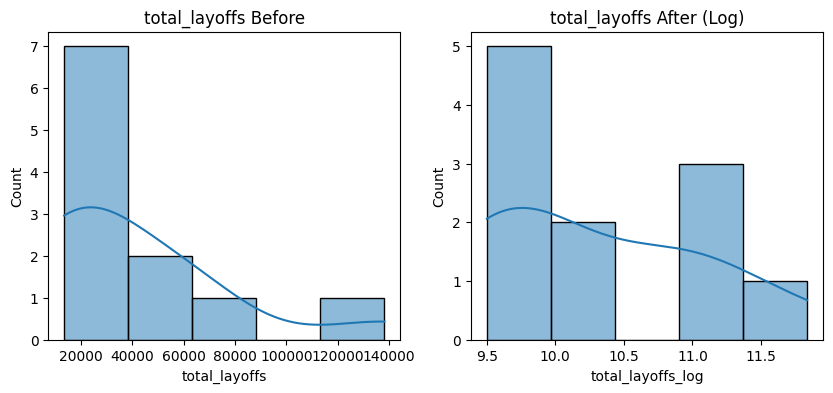

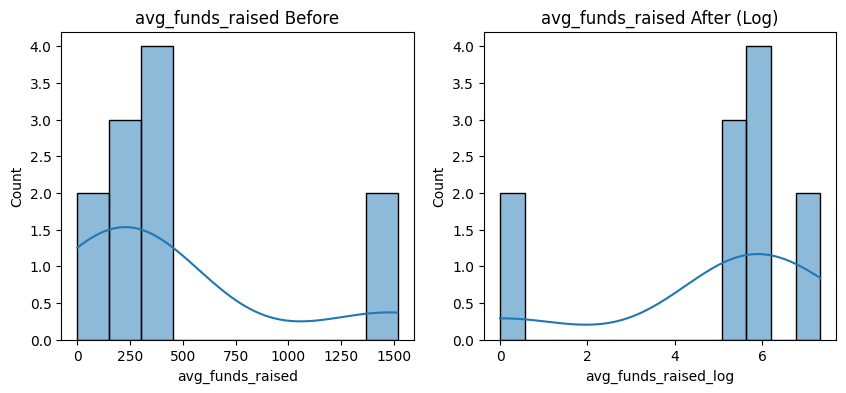

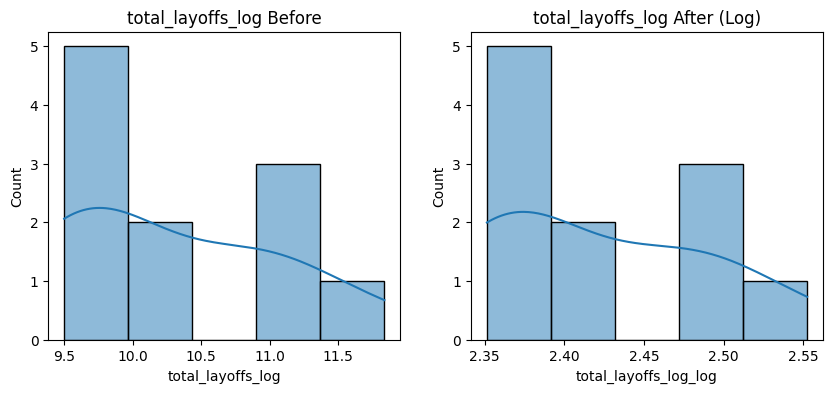


After Transformation Skewness:

total_layoffs → 0.6509806220835299
avg_funds_raised → -1.5459909567493229
total_layoffs_log → 0.5721223953732795


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ds_df.select_dtypes(include='number').columns
skew_vals = ds_df[num_cols].skew()
kurt_vals = ds_df[num_cols].kurtosis()
result = pd.DataFrame({
    'Skewness': skew_vals,
    'Kurtosis': kurt_vals
})

def skew_type(x):
    if x > 0.5:
        return "Right Skewed"
    elif x < -0.5:
        return "Left Skewed"
    else:
        return "Symmetric"

def kurt_type(x):
    if x > 0:
        return "Leptokurtic (Heavy Tails)"
    elif x < 0:
        return "Platykurtic (Light Tails)"
    else:
        return "Mesokurtic (Normal)"

result['Skew_Type'] = result['Skewness'].apply(skew_type)
result['Kurt_Type'] = result['Kurtosis'].apply(kurt_type)
print("\nSkewness & Kurtosis Summary:\n")
display(result)

for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.histplot(ds_df[col], kde=True)
    plt.axvline(ds_df[col].mean(), color='red', linestyle='--', label='Mean')
    plt.axvline(ds_df[col].median(), color='blue', linestyle='-', label='Median')
    plt.title(f"{col} Distribution (Before)")
    plt.legend()
    plt.show()
transformed_cols = []

for col in num_cols:
    if ds_df[col].skew() > 0.5:
        ds_df[col + "_log"] = np.log1p(ds_df[col])
        transformed_cols.append(col)
for col in transformed_cols:
    fig, ax = plt.subplots(1, 2, figsize=(10,4))
    sns.histplot(ds_df[col], kde=True, ax=ax[0])
    ax[0].set_title(f"{col} Before")
    sns.histplot(ds_df[col + "_log"], kde=True, ax=ax[1])
    ax[1].set_title(f"{col} After (Log)")
    plt.show()

print("\nAfter Transformation Skewness:\n")
for col in transformed_cols:
    print(col, "→", ds_df[col + "_log"].skew())

Inferential Statistics:
*   Hypothesis
*  Z test



In [ ]:
# Hypothesis
print("H0: Mean AI Disruption Score of Data Science roles = 0.5")
print("H1: Mean AI Disruption Score of Data Science roles != 0.5")

H0: Mean AI Disruption Score of Data Science roles = 0.5
H1: Mean AI Disruption Score of Data Science roles != 0.5


  Sample Mean         : 0.4847
  Population Mean H0  : 0.5
  Standard Deviation  : 0.1611
  Sample Size (n)     : 11
  Z-Statistic         : -0.3146
  P-Value             : 0.753054
  Critical Value      : ±1.96 (α = 0.05)
  Result: FAIL TO REJECT H0
  Conclusion: AI Disruption is at moderate level
  p = 0.7531 which is greater than 0.05


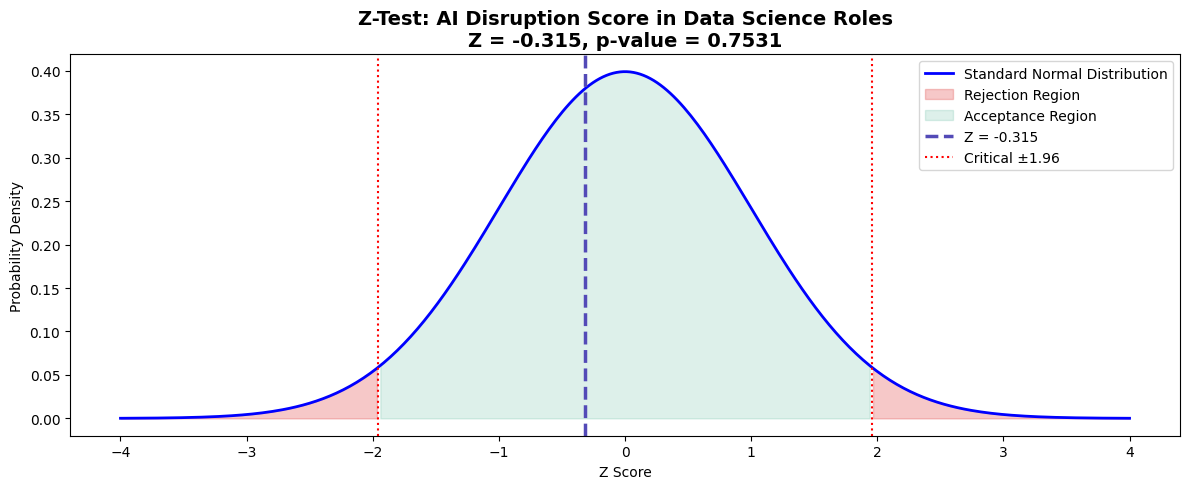

In [ ]:
#Z Test
pop_mean = 0.5

mean = ds_df['ai_disruption_score'].mean()
std = ds_df['ai_disruption_score'].std()
n = len(ds_df)
z = (mean - pop_mean) / (std / np.sqrt(n))

from scipy.stats import norm
p_value = 2 * (1 - norm.cdf(abs(z)))

print(f"  Sample Mean         : {mean:.4f}")
print(f"  Population Mean H0  : {pop_mean}")
print(f"  Standard Deviation  : {std:.4f}")
print(f"  Sample Size (n)     : {n}")
print(f"  Z-Statistic         : {z:.4f}")
print(f"  P-Value             : {p_value:.6f}")
print(f"  Critical Value      : ±1.96 (α = 0.05)")

if abs(z) > 1.96:
    print(f"  Result: REJECT H0")
    print(f"  Conclusion: AI Disruption is significantly different from moderate level")
    print(f"  p = {p_value:.4f} which is less than 0.05")
else:
    print(f"  Result: FAIL TO REJECT H0")
    print(f"  Conclusion: AI Disruption is at moderate level")
    print(f"  p = {p_value:.4f} which is greater than 0.05")

x = np.linspace(-4, 4, 300)
y = norm.pdf(x)

plt.figure(figsize=(12, 5))
plt.plot(x, y, 'b-', linewidth=2, label='Standard Normal Distribution')
plt.fill_between(x, y, where=(x < -1.96), color='#E24B4A', alpha=0.3, label='Rejection Region')
plt.fill_between(x, y, where=(x > 1.96),  color='#E24B4A', alpha=0.3)
plt.fill_between(x, y, where=(x > -1.96) & (x < 1.96), color='#1D9E75', alpha=0.15, label='Acceptance Region')
plt.axvline(z,     color='#534AB7', linestyle='dashed', linewidth=2.5, label=f'Z = {z:.3f}')
plt.axvline(-1.96, color='red',     linestyle='dotted', linewidth=1.5, label='Critical ±1.96')
plt.axvline( 1.96, color='red',     linestyle='dotted', linewidth=1.5)
plt.title(f'Z-Test: AI Disruption Score in Data Science Roles\nZ = {z:.3f}, p-value = {p_value:.4f}', fontsize=14, fontweight='bold')
plt.xlabel('Z Score')
plt.ylabel('Probability Density')
plt.legend()
plt.tight_layout()
plt.show()

ML Model:
*   Models
* Accuracy & Precision
*   Confusion Matrix



  LINEAR REGRESSION - SALARY PREDICTION
  R2 Score  : -0.2330  (-23.3% of salary variance explained)
  MAE       : $19,205
  RMSE      : $25,238

Feature Coefficients:
            Feature  Coefficient
ai_disruption_score 16462.526317
     avg_layoff_pct -9506.227119
      total_layoffs -6430.862415
         risk_score -4692.729391
    automation_risk  4692.729391
        ai_adoption  3700.157418


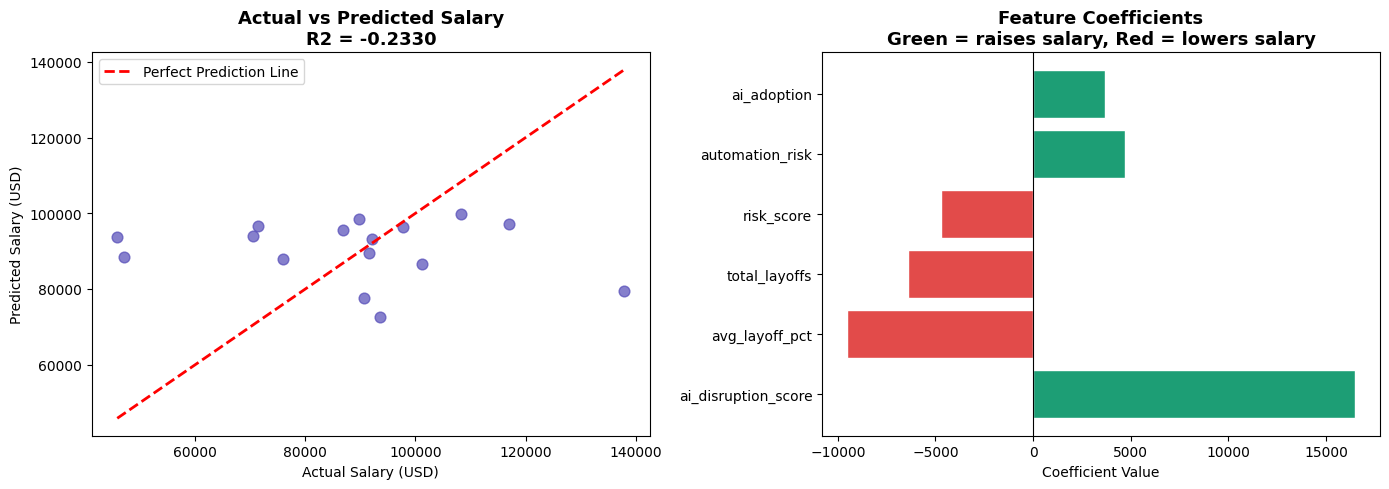

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

df_lr = df4.copy()
df_lr['automation_risk_enc'] = LabelEncoder().fit_transform(df_lr['automation_risk'])
df_lr['ai_adoption_enc']     = LabelEncoder().fit_transform(df_lr['ai_adoption_level'])

X_lr = df_lr[['ai_disruption_score', 'risk_score', 'automation_risk_enc',
               'ai_adoption_enc', 'total_layoffs', 'avg_layoff_pct']]
y_lr = df_lr['salary_usd']
scaler_lr = StandardScaler()
X_lr_scaled = scaler_lr.fit_transform(X_lr)
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_lr_scaled, y_lr, test_size=0.2, random_state=42)
lr_model = LinearRegression()
lr_model.fit(X_train_lr, y_train_lr)
y_pred_lr = lr_model.predict(X_test_lr)
r2   = r2_score(y_test_lr, y_pred_lr)
mae  = mean_absolute_error(y_test_lr, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test_lr, y_pred_lr))

print("  LINEAR REGRESSION - SALARY PREDICTION")
print(f"  R2 Score  : {r2:.4f}  ({r2*100:.1f}% of salary variance explained)")
print(f"  MAE       : ${mae:,.0f}")
print(f"  RMSE      : ${rmse:,.0f}")

coef_df = pd.DataFrame({
    'Feature'    : ['ai_disruption_score', 'risk_score', 'automation_risk',
                    'ai_adoption', 'total_layoffs', 'avg_layoff_pct'],
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)
print("\nFeature Coefficients:")
print(coef_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test_lr, y_pred_lr, color='#534AB7', alpha=0.7, s=60)
mn, mx = min(y_test_lr.min(), y_pred_lr.min()), max(y_test_lr.max(), y_pred_lr.max())
axes[0].plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Perfect Prediction Line')
axes[0].set_title(f'Actual vs Predicted Salary\nR2 = {r2:.4f}', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Actual Salary (USD)')
axes[0].set_ylabel('Predicted Salary (USD)')
axes[0].legend()

colors_c = ['#1D9E75' if c >= 0 else '#E24B4A' for c in coef_df['Coefficient']]
axes[1].barh(coef_df['Feature'], coef_df['Coefficient'], color=colors_c, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Feature Coefficients\nGreen = raises salary, Red = lowers salary', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Coefficient Value')

plt.tight_layout()
plt.show()

In [ ]:
# Results
print(f"  Total Samples    : {len(df_model)}")
print(f"  Training Samples : {len(X_train)}")
print(f"  Testing Samples  : {len(X_test)}")
print(f"  Accuracy         : {round(accuracy_score(y_test, y_pred) * 100, 2)}%")
print(f"  Precision        : {round(precision_score(y_test, y_pred, average='weighted') * 100, 2)}%")
print("  Target           : High Risk | Low Risk | Medium Risk")
print("  Features         : AI Disruption Score, Automation Risk,")
print("                     AI Adoption Level, Salary, Risk Score")

  Total Samples    : 78
  Training Samples : 62
  Testing Samples  : 16
  Accuracy         : 93.75%
  Precision        : 95.83%
  Target           : High Risk | Low Risk | Medium Risk
  Features         : AI Disruption Score, Automation Risk,
                     AI Adoption Level, Salary, Risk Score


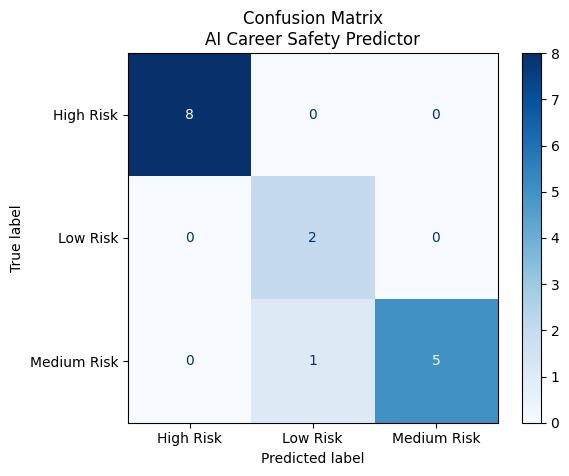

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix\nAI Career Safety Predictor")
plt.show()

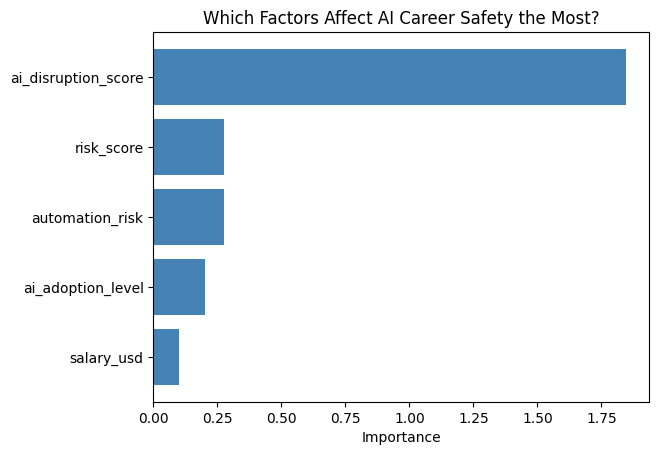

In [ ]:
import pandas as pd

# Feature Importance from model coefficients
features = ['ai_disruption_score', 'automation_risk', 'ai_adoption_level', 'salary_usd', 'risk_score']
importance = pd.DataFrame({
    'Feature': features,
    'Importance': abs(model.coef_).mean(axis=0)
}).sort_values('Importance', ascending=True)

plt.barh(importance['Feature'], importance['Importance'], color='steelblue')
plt.title("Which Factors Affect AI Career Safety the Most?")
plt.xlabel("Importance")
plt.show()

/tmp/ipykernel_3843/2379053149.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df4, x='career_safety', order=order, palette=palette, ax=axes[0], edgecolor='white')


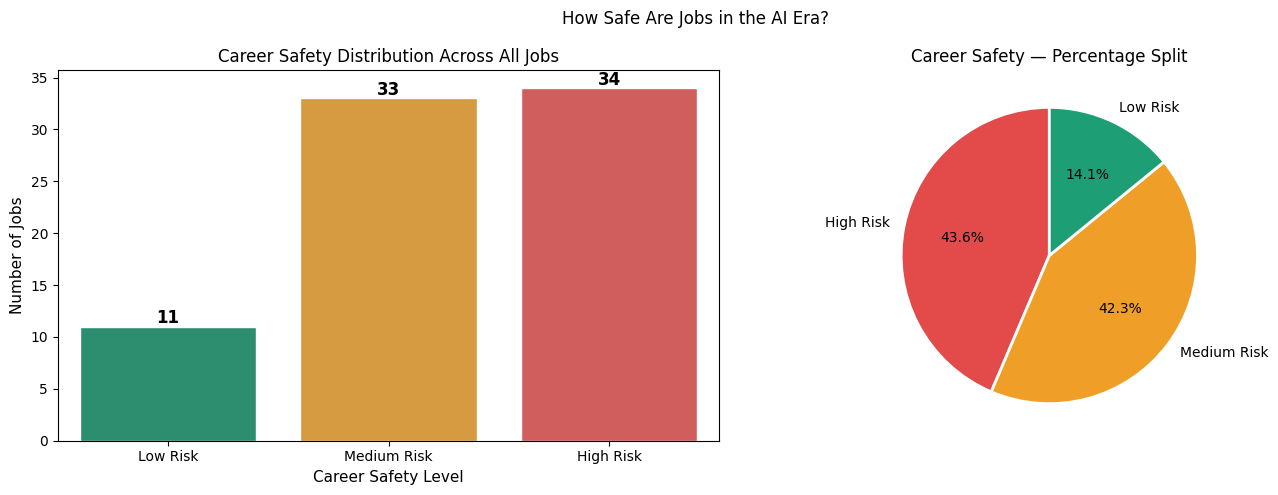

In [ ]:
#visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order = ['Low Risk', 'Medium Risk', 'High Risk']
palette = {'Low Risk': '#1D9E75', 'Medium Risk': '#EF9F27', 'High Risk': '#E24B4A'}

sns.countplot(data=df4, x='career_safety', order=order, palette=palette, ax=axes[0], edgecolor='white')
axes[0].set_title('Career Safety Distribution Across All Jobs')
axes[0].set_xlabel('Career Safety Level', fontsize=11)
axes[0].set_ylabel('Number of Jobs', fontsize=11)
for p in axes[0].patches:
    axes[0].annotate(str(int(p.get_height())),
                     (p.get_x() + p.get_width() / 2, p.get_height() + 0.3),
                     ha='center', fontsize=12, fontweight='bold')

sizes = df4['career_safety'].value_counts()
colors = [palette.get(k, 'gray') for k in sizes.index]
axes[1].pie(sizes, labels=sizes.index, autopct='%1.1f%%', colors=colors,
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Career Safety — Percentage Split')

plt.suptitle('How Safe Are Jobs in the AI Era?')
plt.tight_layout()
plt.show()

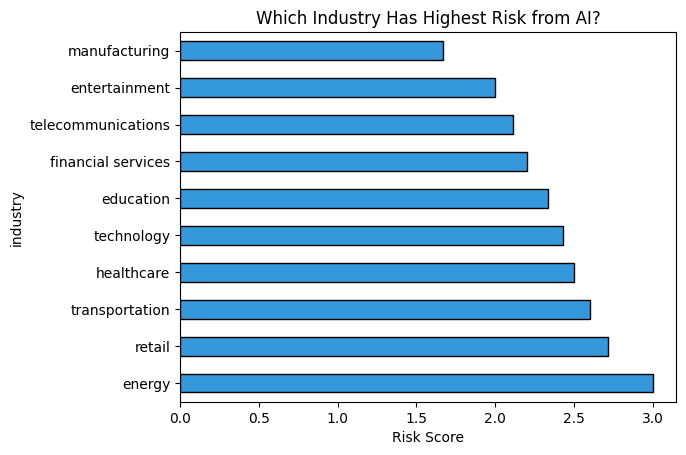

In [ ]:
df4.groupby('industry')['risk_score'].mean().sort_values(ascending=False).plot(
    kind='barh', color='#3498db', edgecolor='black')
plt.title("Which Industry Has Highest Risk from AI?")
plt.xlabel("Risk Score")
plt.show()

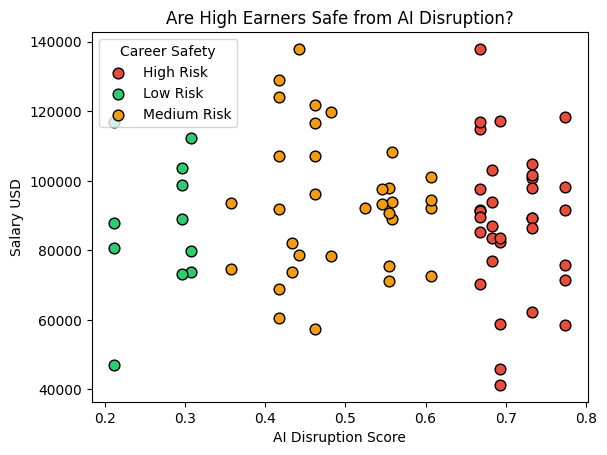

In [ ]:
colors = {'High Risk':'#e74c3c', 'Medium Risk':'#f39c12', 'Low Risk':'#2ecc71'}
for safety, group in df4.groupby('career_safety'):
    plt.scatter(group['ai_disruption_score'], group['salary_usd'],
                label=safety, color=colors[safety], edgecolors='black', s=60)
plt.title("Are High Earners Safe from AI Disruption?")
plt.xlabel("AI Disruption Score")
plt.ylabel("Salary USD")
plt.legend(title="Career Safety")
plt.show()